#1. Data collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# glob is a package that is specifically used when we have to search some files which has some special kind of
# extension or it has some specific file pattern

In [2]:
import glob

In [3]:
glob.glob(r'/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/*csv')

['/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/APH_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/BBT_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/ADSK_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/ALK_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AFL_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/ADP_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AON_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/APC_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AMGN_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AIZ_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AZO_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-2026

In [4]:
len(glob.glob(r'/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/*csv'))

100

In [5]:
company_list = [
     r'/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AAPL_data.csv',
     r'/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AMZN_data.csv',

]

In [7]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [13]:
df_list = []

for file in company_list:
    df_list.append(pd.read_csv(file))

all_data = pd.concat(df_list, ignore_index=True)

In [15]:
all_data.shape

(2518, 7)

In [16]:
all_data.head(6)

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL
5,2013-02-15,66.9785,67.1656,65.7028,65.7371,97924631,AAPL


In [17]:
all_data['Name'].unique()

array(['AAPL', 'AMZN'], dtype=object)

# 2.What was the change in price of the stock overtime?

In [19]:
all_data.isnull().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

In [20]:
all_data.dtypes

date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object

In [23]:
all_data['date'] = pd.to_datetime(all_data['date'])  #converting datatype of "date" feature into date-time

In [24]:
all_data['date'] 

0      2013-02-08
1      2013-02-11
2      2013-02-12
3      2013-02-13
4      2013-02-14
          ...    
2513   2018-02-01
2514   2018-02-02
2515   2018-02-05
2516   2018-02-06
2517   2018-02-07
Name: date, Length: 2518, dtype: datetime64[ns]

In [27]:
tech_list = all_data['Name'].unique()

In [28]:
tech_list

array(['AAPL', 'AMZN'], dtype=object)

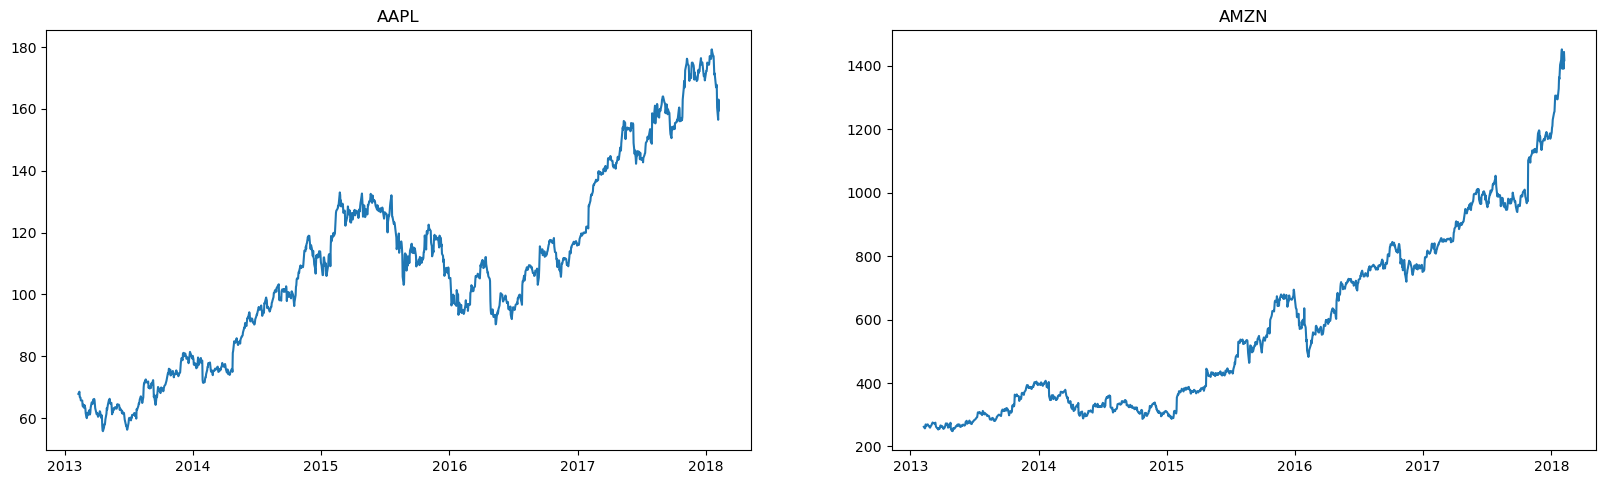

In [30]:
plt.figure(figsize=(20,12))

for index, company in enumerate( tech_list,1):
    plt.subplot(2,2,index)
    filter1 = all_data['Name']== company
    df = all_data[filter1]
    plt.plot(df['date'],df['close'])
    plt.title(company)

# What was the moving average of the various stocks?

In [31]:
all_data.head(15)

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL
5,2013-02-15,66.9785,67.1656,65.7028,65.7371,97924631,AAPL
6,2013-02-19,65.8714,66.1042,64.8356,65.7128,108854046,AAPL
7,2013-02-20,65.3842,65.3842,64.1142,64.1214,118891367,AAPL
8,2013-02-21,63.7142,64.1671,63.2599,63.7228,111596821,AAPL
9,2013-02-22,64.1785,64.5142,63.7999,64.4014,82583823,AAPL


In [33]:
all_data['close']

0         67.8542
1         68.5614
2         66.8428
3         66.7156
4         66.6556
          ...    
2513    1390.0000
2514    1429.9500
2515    1390.0000
2516    1442.8400
2517    1416.7800
Name: close, Length: 2518, dtype: float64

In [37]:
all_data['close'].rolling(window=10).mean().head(14)

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8          NaN
9     66.03251
10    65.57280
11    65.13051
12    64.79722
13    64.43137
Name: close, dtype: float64

In [38]:
new_data= all_data.copy()

In [40]:
ma_day = [10,20, 50]

for ma in ma_day:
     new_data['close_'+str(ma)] = new_data['close'].rolling(ma).mean()

In [42]:
new_data.tail(7)

,date,open,high,low,close,volume,Name,close_10,close_20,close_50
2511,2018-01-30,1403.17,1439.25,1392.00,1437.82,5871942,AMZN,1356.576,1301.9170,1220.3550
2512,2018-01-31,1451.30,1472.58,1450.04,1450.89,6424693,AMZN,1372.165,1315.0110,1226.6270
2513,2018-02-01,1445.00,1459.88,1385.14,1390.00,9113808,AMZN,1381.833,1324.3010,1231.8294
2514,2018-02-02,1477.39,1498.00,1414.00,1429.95,11125722,AMZN,1395.370,1335.3190,1237.9022
2515,2018-02-05,1402.62,1458.98,1320.72,1390.00,11494985,AMZN,1401.639,1343.3620,1242.9124
2516,2018-02-06,1361.46,1443.99,1351.79,1442.84,11066819,AMZN,1409.669,1353.1605,1248.6460
2517,2018-02-07,1449.00,1460.99,1415.15,1416.78,7162741,AMZN,1415.596,1361.3645,1253.2616


In [ ]:
new_data.set_index('date' , inplace=True)

In [44]:
new_data

,date,open,high,low,close,volume,Name,close_10,close_20,close_50
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,NaN,NaN,NaN
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,NaN,NaN,NaN
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,NaN,NaN,NaN
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,NaN,NaN,NaN
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2513,2018-02-01,1445.0000,1459.8800,1385.1400,1390.0000,9113808,AMZN,1381.833,1324.3010,1231.8294
2514,2018-02-02,1477.3900,1498.0000,1414.0000,1429.9500,11125722,AMZN,1395.370,1335.3190,1237.9022
2515,2018-02-05,1402.6200,1458.9800,1320.7200,1390.0000,11494985,AMZN,1401.639,1343.3620,1242.9124
2516,2018-02-06,1361.4600,1443.9900,1351.7900,1442.8400,11066819,AMZN,1409.669,1353.1605,1248.6460


In [46]:
new_data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name', 'close_10',
       'close_20', 'close_50'],
      dtype='object')

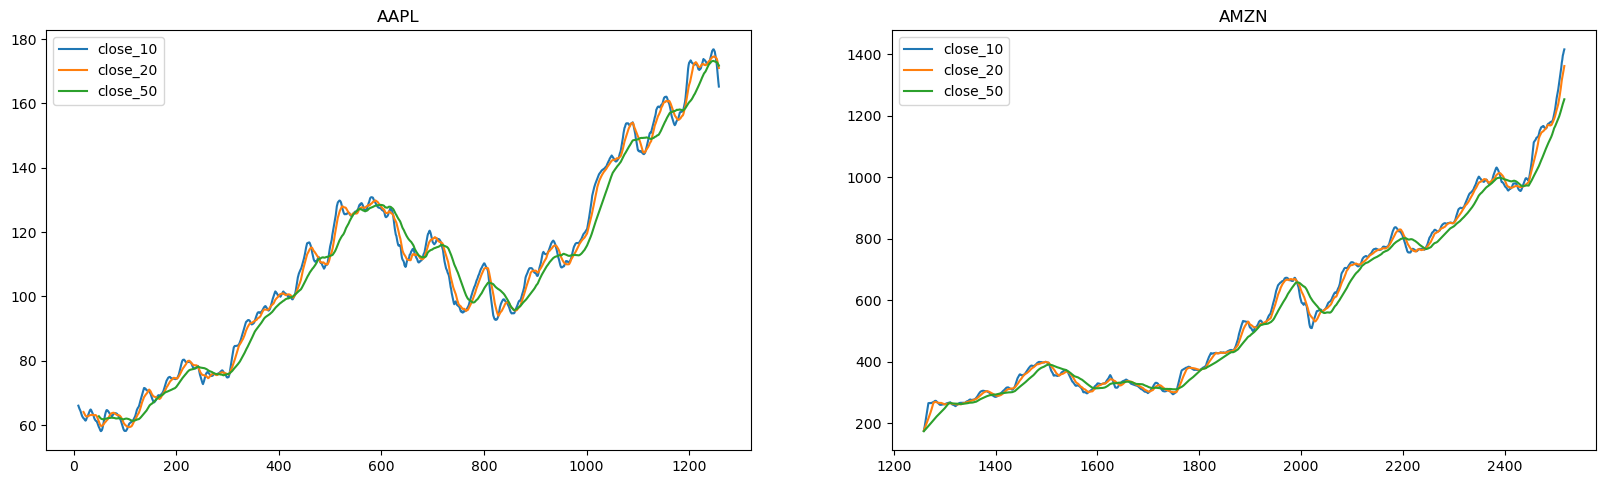

In [47]:
plt.figure(figsize=(20,12))

for index, company in enumerate( tech_list,1):
    plt.subplot(2,2,index)
    filter1 = new_data['Name']== company
    df = new_data[filter1]
    df[['close_10','close_20', 'close_50']].plot(ax=plt.gca())
    plt.title(company)

# 3.analyse closing price change in apple stock

In [48]:
company_list

['/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AAPL_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AMZN_data.csv']

In [52]:
apple = pd.read_csv(r'/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AAPL_data.csv')

In [57]:
apple.head(4)

,date,open,high,low,close,volume,Name,Daily return(in %
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,NaN
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,1.042235
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,-2.506658
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,-0.190297


In [54]:
apple['close']

0        67.8542
1        68.5614
2        66.8428
3        66.7156
4        66.6556
          ...   
1254    167.7800
1255    160.5000
1256    156.4900
1257    163.0300
1258    159.5400
Name: close, Length: 1259, dtype: float64

In [58]:
apple['Daily return(in %']= apple['close'].pct_change()*100

In [59]:
apple.head(4)

,date,open,high,low,close,volume,Name,Daily return(in %
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,NaN
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,1.042235
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,-2.506658
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,-0.190297


In [ ]:
import plotly.express as px 

In [ ]:
px.line(apple, x="date", y="Daily return(in %")

# 4.performing resampling analysis of closing price 

In [60]:
apple.dtypes

date                  object
open                 float64
high                 float64
low                  float64
close                float64
volume                 int64
Name                  object
Daily return(in %    float64
dtype: object

In [61]:
apple['date'] = pd.to_datetime(apple['date'])

In [62]:
apple.dtypes

date                 datetime64[ns]
open                        float64
high                        float64
low                         float64
close                       float64
volume                        int64
Name                         object
Daily return(in %           float64
dtype: object

In [ ]:
apple.head(4)

In [63]:
apple.set_index('date', inplace = True)

In [64]:
apple.head(4)

,open,high,low,close,volume,Name,Daily return(in %
date,,,,,,,
2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,NaN
2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,1.042235
2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,-2.506658
2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,-0.190297


In [65]:
# Montly base analysis

apple['close'].resample('M').mean()

date
2013-02-28     65.306264
2013-03-31     63.120110
2013-04-30     59.966432
2013-05-31     63.778927
2013-06-30     60.791120
                 ...    
2017-10-31    157.817273
2017-11-30    172.406190
2017-12-31    171.891500
2018-01-31    174.005238
2018-02-28    161.468000
Freq: ME, Name: close, Length: 61, dtype: float64

<Axes: xlabel='date'>

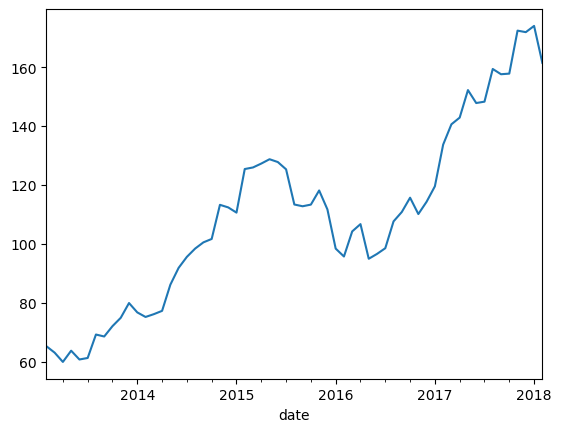

In [73]:

apple['close'].resample('M').mean().plot()

In [68]:
# Yearly base analysis
apple['close'].resample('Y').mean()

date
2013-12-31     67.237839
2014-12-31     92.264531
2015-12-31    120.039861
2016-12-31    104.604008
2017-12-31    150.585080
2018-12-31    171.594231
Freq: YE-DEC, Name: close, dtype: float64

<Axes: xlabel='date'>

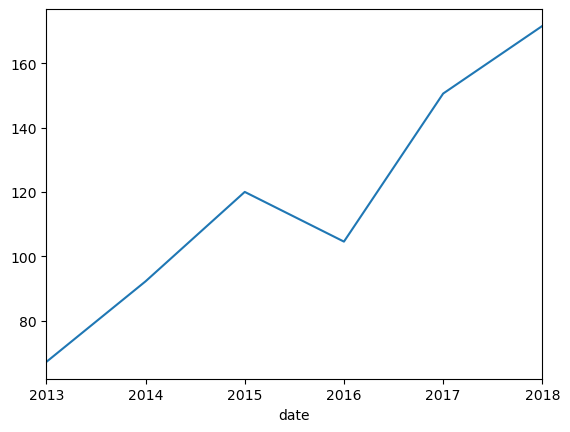

In [67]:
apple['close'].resample('Y').mean().plot()

In [71]:
# Quaterly base analysis
apple['close'].resample('Q').mean()

date
2013-03-31     64.020291
2013-06-30     61.534692
2013-09-30     66.320670
2013-12-31     75.567478
2014-03-31     76.086293
2014-06-30     85.117475
2014-09-30     98.163311
2014-12-31    108.821016
2015-03-31    120.776721
2015-06-30    127.937937
2015-09-30    117.303438
2015-12-31    114.299297
2016-03-31     99.655082
2016-06-30     99.401250
2016-09-30    105.866094
2016-12-31    113.399048
2017-03-31    131.712500
2017-06-30    147.875397
2017-09-30    155.304603
2017-12-31    167.148254
2018-03-31    171.594231
Freq: QE-DEC, Name: close, dtype: float64

<Axes: xlabel='date'>

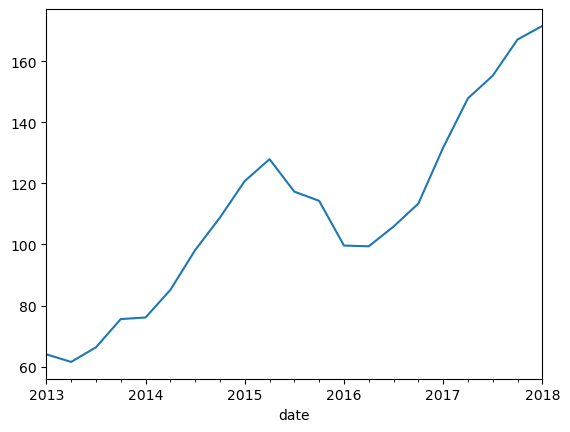

In [72]:
apple['close'].resample('Q').mean().plot()

# 5.Checking if the closing prices of these tech companies (amazon, apple, google, microsoft) are correlated or not

In [74]:
company_list

['/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AAPL_data.csv',
 '/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AMZN_data.csv']

In [75]:
company_list[0]

'/Users/komaljondhale/Downloads/drive-download-20260221T114732Z-1-001/AAPL_data.csv'

In [76]:
app = pd.read_csv(company_list[0])
amzn  = pd.read_csv(company_list[1])


In [77]:
closing_price = pd.DataFrame()

In [79]:
closing_price['apple_close'] = app['close']
closing_price['amzn_close'] = amzn['close']

In [81]:
closing_price

,apple_close,amzn_close
0,67.8542,261.95
1,68.5614,257.21
2,66.8428,258.70
3,66.7156,269.47
4,66.6556,269.24
...,...,...
1254,167.7800,1390.00
1255,160.5000,1429.95
1256,156.4900,1390.00
1257,163.0300,1442.84


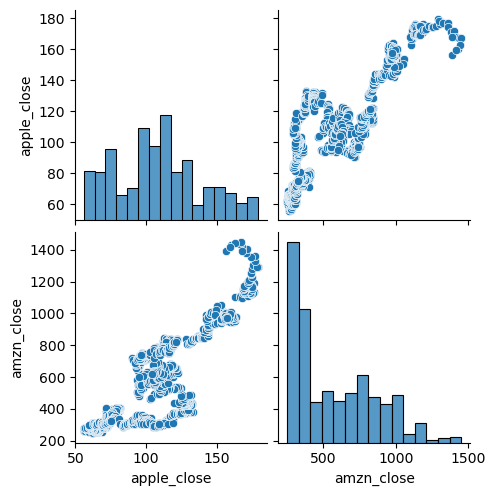

In [82]:
sns.pairplot(closing_price)  

In [83]:
closing_price.corr()

,apple_close,amzn_close
apple_close,1.000000,0.819078
amzn_close,0.819078,1.000000


<Axes: >

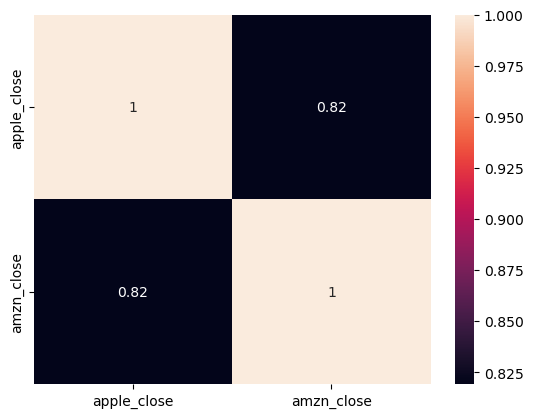

In [85]:
sns.heatmap(closing_price.corr(), annot=True)

# Analyse whether daily change in closing price of stocks or daily returns in stock are co-related or not?

In [86]:
closing_price

,apple_close,amzn_close
0,67.8542,261.95
1,68.5614,257.21
2,66.8428,258.70
3,66.7156,269.47
4,66.6556,269.24
...,...,...
1254,167.7800,1390.00
1255,160.5000,1429.95
1256,156.4900,1390.00
1257,163.0300,1442.84


In [87]:
closing_price['apple_close']

0        67.8542
1        68.5614
2        66.8428
3        66.7156
4        66.6556
          ...   
1254    167.7800
1255    160.5000
1256    156.4900
1257    163.0300
1258    159.5400
Name: apple_close, Length: 1259, dtype: float64

In [88]:
closing_price['apple_close'].shift(1)

0            NaN
1        67.8542
2        68.5614
3        66.8428
4        66.7156
          ...   
1254    167.4300
1255    167.7800
1256    160.5000
1257    156.4900
1258    163.0300
Name: apple_close, Length: 1259, dtype: float64

In [91]:
closing_price['apple_close'] - closing_price['apple_close'].shift(1)/ closing_price['apple_close'].shift(1) *100

0           NaN
1      -31.4386
2      -33.1572
3      -33.2844
4      -33.3444
         ...   
1254    67.7800
1255    60.5000
1256    56.4900
1257    63.0300
1258    59.5400
Name: apple_close, Length: 1259, dtype: float64

In [94]:
for col in closing_price.columns: 
    closing_price[col + '_pct_change'] = closing_price[col] - closing_price[col].shift(1)/ closing_price[col].shift(1) *100

In [96]:
closing_price.columns

Index(['apple_close', 'amzn_close', 'apple_close_pct_change',
       'amzn_close_pct_change'],
      dtype='object')

In [98]:
closing_p = closing_price[['apple_close', 'amzn_close', 'apple_close_pct_change',
       'amzn_close_pct_change']]

In [99]:
closing_p

,apple_close,amzn_close,apple_close_pct_change,amzn_close_pct_change
0,67.8542,261.95,NaN,NaN
1,68.5614,257.21,-31.4386,157.21
2,66.8428,258.70,-33.1572,158.70
3,66.7156,269.47,-33.2844,169.47
4,66.6556,269.24,-33.3444,169.24
...,...,...,...,...
1254,167.7800,1390.00,67.7800,1290.00
1255,160.5000,1429.95,60.5000,1329.95
1256,156.4900,1390.00,56.4900,1290.00
1257,163.0300,1442.84,63.0300,1342.84


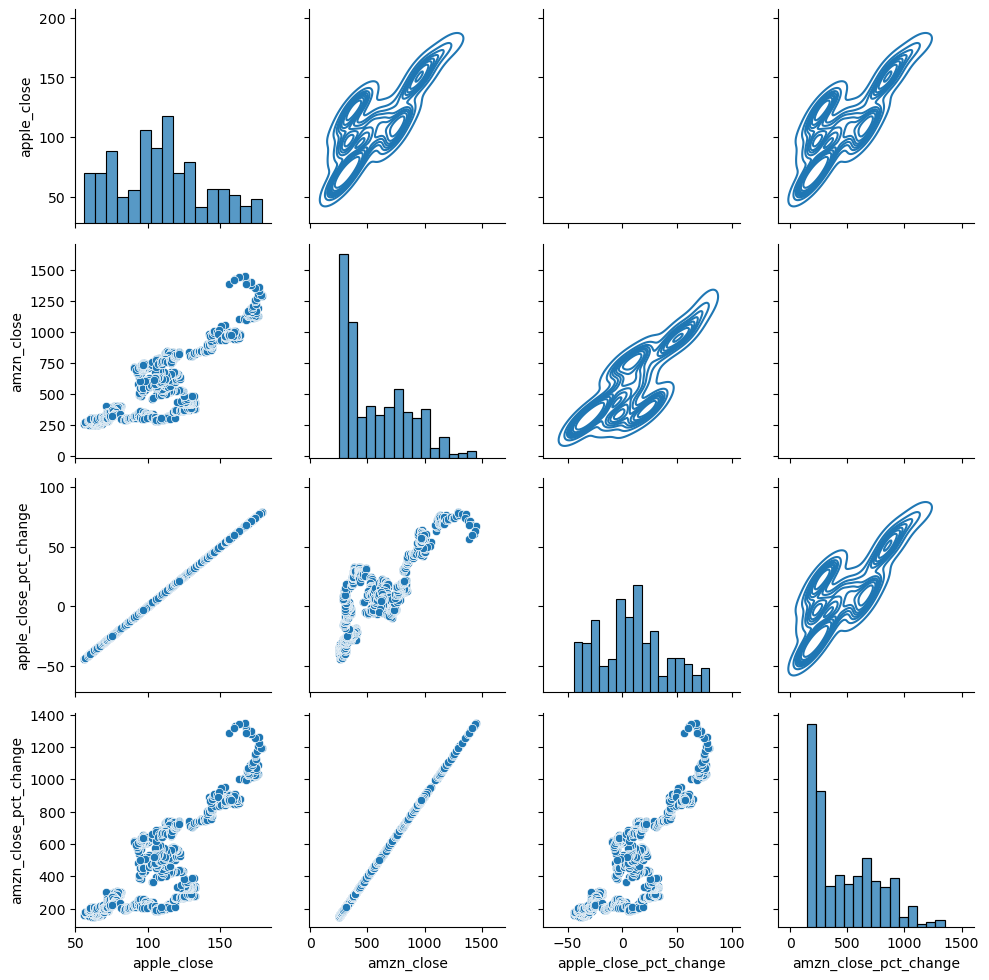

In [103]:
g = sns.PairGrid(data=closing_p)
g.map_diag(sns.histplot)
g.map_lower(sns.scatterplot)
g.map_upper(sns.kdeplot)

In [104]:
closing_p.corr()

,apple_close,amzn_close,apple_close_pct_change,amzn_close_pct_change
apple_close,1.000000,0.819078,1.00000,0.81888
amzn_close,0.819078,1.000000,0.81888,1.00000
apple_close_pct_change,1.000000,0.818880,1.00000,0.81888
amzn_close_pct_change,0.818880,1.000000,0.81888,1.00000
